In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity 
from sklearn.metrics import pairwise_distances, mean_absolute_error, mean_squared_error

In [2]:
QUARTERS_ORDER = ['Q1_2019', 'Q2_2019', 'Q3_2019', 'Q4_2019', 'Q1_2020', 'Q2_2020', 'Q3_2020', 'Q4_2020']

In [3]:
# data preprocessing - aggregating data from both years
df_runners_2019 = pd.read_csv('data/run_ww_2019_q.csv')
df_runners_2020 = pd.read_csv('data/run_ww_2020_q.csv')
df_runners = pd.concat([df_runners_2019, df_runners_2020])
df_runners.reset_index(inplace = True, drop = True)
df_runners['datetime'] = pd.to_datetime(df_runners['datetime'])
df_runners['quarter'] = 'Q' + df_runners['datetime'].dt.quarter.astype(str) + '_' + df_runners['datetime'].dt.year.astype(str)

# removing demographic info from main data
df_performance = df_runners.drop(columns = ['country', 'gender', 'number', 'major', 'age_group', 'datetime'])

# collecting demographic info for additional match
df_demographic = df_runners[['athlete', 'country', 'gender', 'age_group']].drop_duplicates('athlete').set_index('athlete')

In [4]:
def create_pivot(df, value):
    """Creates a pivot table that has athletes as the index and the quarterly values as columns
    Args:
        df (DataFrame): data to pivot (consists info taken over 1 year, timestamped to the quarter close)
        value (str): feature column to use for pivot values
    Returns:
        pivot (DataFrame): df of runners quartely info
    """
    pivot = df.pivot_table(index = 'athlete', columns = 'quarter', values = value)
    pivot.columns = [f'{value}_{quarter}' for quarter in pivot.columns]
    return pivot

In [5]:
def calc_similarities(df, target, sim = 'cosine'):
    """Calculates similaty scores for a target runner and all other runners
    Args:
        df (DataFrame): pivoted df with runners and quarterly info
        target (int): athlete number to find similarities for
        sim (str): similariy method (cosine or L2); default is cosine    
    Returns:
        similarities (Series): pd series of similarity scores between target runners and other runners
    """
    # pairwise sim scores (only for target runner)
    if sim == 'cosine':
        similarity_matrix = cosine_similarity(df.loc[[target]], df)
        similarities = pd.Series(similarity_matrix[0], index = df.index)
    elif sim == 'L2':
        distances = pairwise_distances(df.loc[[target]], df, metric='euclidean')[0]
        similarities = pd.Series(-distances, index=df.index)
        
    return similarities

In [6]:
def demographic_similarity(df_demographic, target_idx):
    """Computes demographic similarity for target vs all athletes.   
    Args:
        df_demographic (DataFrame): athlete-indexed df with demographic columns
        target (int): athlete to compute similarities for     
    Returns:
        demographic similarity scores
    """
    target_runner = df_demographic.loc[target_idx]
    weight = 1 / len(df_demographic.columns)
    
    scores = pd.Series(0, index=df_demographic.index)
    for col in df_demographic.columns:
        scores += weight * (df_demographic[col] == target_runner[col]).astype(float)
        
    return scores

In [7]:
def runner_collab_filter(df_performance, target, df_demographic, features=['distance', 'duration'], sim = 'L2', k = 3, predict_missing=True, alpha = 0.8):
    """Collaborative filtering to find most similar runners or predict missing features, based on the averaged similarity
    scores of all features
    Args:
        df_performance (DataFrame): runner data with an entry per runner per quarter
        target (int): target runner to find most similar runners
        df_demographic (DataFrame): runner demographic data to find also find demographic matches
        features (list): list of features to use to determine similarity
        sim (str): similariy method (cosine or L2); default is L2
        k (int): number of neighbors to find; default is 3
        predict_missing (bool): optional to fill any missing values based on k most similar runners
        alpha (float): determines balance of the influence running data and demographic data has on similarities;
                        (1 = only use running performance, 0 = only use demographic info); default is 0.8    
    Returns:
        (dict): dictionary containing k closest runners 'running_buddies' and their corresponding similarity 
                scores 'similarities', the missing predictions if any 'predictions', the k furthest runners 'least_match'
                and their corresponding similarity scores 'least_similarities'
    """
    # compute similarities for each feature and average all similarities
    all_similarities = []
    pivots = {}
    # creating pivots and finding similarites for all features
    for feature in features:
        pivot = create_pivot(df_performance, feature)
        pivots[feature] = pivot        
        # ensuring target runner exists in df_performance
        if target not in pivot.index:
            print(f"Error: {target} not found in {feature} pivot.")
            return None
        similarities = calc_similarities(pivot, target, sim = sim)
        all_similarities.append(similarities)
    
    # finding most similar runners on average (based on averaged sim scores across all targeted features)
    avg_similarities = pd.concat(all_similarities, axis = 1).mean(axis = 1)
    
    # finding demographically similar runners
    demographic_similarities = demographic_similarity(df_demographic, target)
    avg_similarities, demographic_similarities = avg_similarities.align(demographic_similarities, fill_value=np.nan)
    avg_similarities = alpha * avg_similarities.fillna(0) + (1 - alpha) * demographic_similarities.fillna(0)
    
    # min-max scaling similarities
    avg_similarities = (avg_similarities - avg_similarities.min()) / (avg_similarities.max() - avg_similarities.min())
    
    # removing self-similarity
    avg_similarities[target] = np.nan

    # find k closest runners
    k_closest = avg_similarities.nlargest(k).index
    weights = avg_similarities[k_closest]
    k_furthest = avg_similarities.nsmallest(k).index

    # predict missing values per feature using original pivot
    predictions = {}
    if predict_missing:
        for feature, pivot in pivots.items():
            missing_cols = [col for col in pivot.columns if pd.isna(pivot.loc[target, col])]
            if missing_cols:
                neighbor_vals = pivot.loc[k_closest, missing_cols].copy()
                neighbor_vals = neighbor_vals.fillna(neighbor_vals.mean())
                predictions[feature] = (neighbor_vals.T.dot(weights) / weights.sum()).to_dict()
                
    return {'running_buddies': k_closest, 
            'similarities': avg_similarities[k_closest].round(4),
            'predictions': predictions,
            'least_match': k_furthest,
            'least_similarities': avg_similarities[k_furthest].round(4)}

In [8]:
running_match = runner_collab_filter(df_performance, 2, df_demographic)
running_match

{'running_buddies': Index([32561, 29078, 6941], dtype='int64', name='athlete'),
 'similarities': athlete
 32561    0.9855
 29078    0.9835
 6941     0.9826
 dtype: float64,
 'predictions': {},
 'least_match': Index([32408, 1650, 24379], dtype='int64', name='athlete'),
 'least_similarities': athlete
 32408    0.0000
 1650     0.2564
 24379    0.3085
 dtype: float64}

In [9]:
def plot_similarity(df_performance, results, target, most_least = 'most'):
    """Plots comparison of target runners and collaborative filtering designated closest runners
    Args:
        df_performance (DataFrame): runner data with an entry per runner per quarter
        results (dict): dictionary containing k closest runners 'running_buddies' and their corresponding similarity 
                        scores 'similarities', and the missing predictions if any 'predictions'
        target (int): target runner to find most similar runners
        most_least (str): whether to display most similar or least similar runners; default is 'most'
    """
    if most_least == 'most':
        buddies = list(results['running_buddies'])
        similarities = results['similarities']
    if most_least == 'least':
        buddies = list(results['least_match'])
        similarities = results['least_similarities']
    group = [target] + buddies

    distance_pivot = create_pivot(df_performance, 'distance')
    duration_pivot = create_pivot(df_performance, 'duration')
    
    dist_cols = [f'distance_{q}' for q in QUARTERS_ORDER]
    dur_cols  = [f'duration_{q}' for q in QUARTERS_ORDER]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 7))

    # plotting each athlete to compate to target
    for athlete in group:
        label = f'Runner {athlete} (target)' if athlete == target else f'Runner {athlete} (sim: {similarities[athlete]})'
        # making target line stand out
        lw = 2.5 if athlete == target else 1.5
        ls = '-'  if athlete == target else '--'
        ax1.plot(QUARTERS_ORDER, distance_pivot.loc[athlete, dist_cols].values, label=label, linewidth=lw, linestyle=ls, marker='o')
        ax2.plot(QUARTERS_ORDER, duration_pivot.loc[athlete, dur_cols].values,  label=label, linewidth=lw, linestyle=ls, marker='o')
    
    # finishing touches for plot
    ax1.set_title('Distance')
    ax1.set_xlabel('Quarter')
    ax1.set_ylabel('Total Distance')
    ax2.set_title('Duration')
    ax2.set_xlabel('Quarter')
    ax2.set_ylabel('Total Duration')
    ax1.tick_params(axis='x', rotation=45)
    ax2.tick_params(axis='x', rotation=45)
    ax1.legend()
    ax2.legend()
    
    if most_least == 'most':
        fig.suptitle(f'Running Buddies for Runner {target}')
    if most_least == 'least':
        fig.suptitle(f'Least Match for Runner {target}')
        
    plt.tight_layout()
    plt.show()

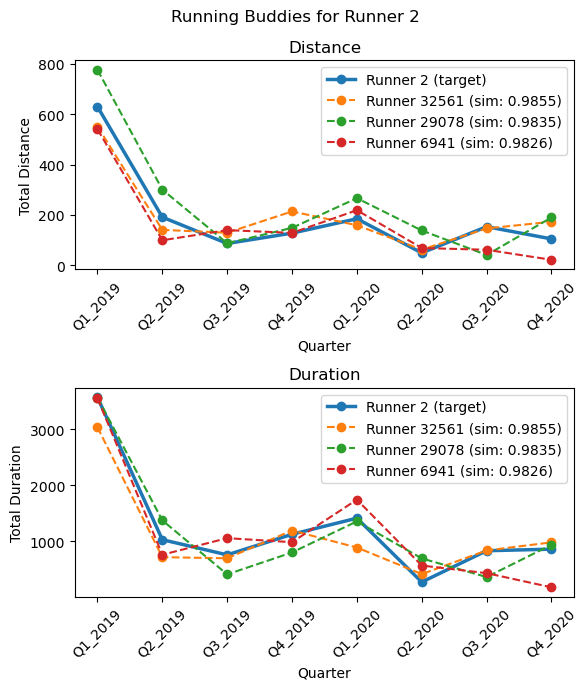

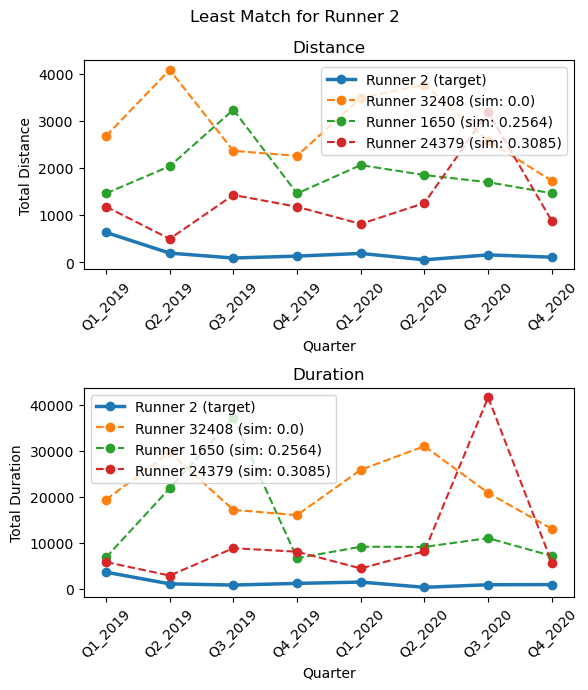

In [10]:
target = 2
results = runner_collab_filter(df_performance, target, df_demographic)
plot_similarity(df_performance, results, target)
plot_similarity(df_performance, results, target, most_least = 'least')

In [11]:
def predict(df_runners, feature, k=3, sim = 'L2', n = 10000, baseline = False):
    """Predicts running performance and calculates metrics (MAE and RMSE) using 2019 data as train and 2020 as test
    Args:
        df_runners (DataFrame): full runner data with an entry per runner per quarter
        feature (str): feature to calculate metrics for (distance or duration)
        k (int): number of neighbors to find; default is 5
        sim (str): similariy method (cosine or L2); default is L2
        n (int): subset size; default is 10000
        baseline (bool): whether to calculate baseline metrics; default is False
    Returns:
        results (dict): MAE or RMSE, as well as baseline MAE and RMSE if baseline == True
    """
    np.random.seed(42)
    results = {}
    
    # using 2019 data to predict 2020
    df_2019 = df_runners[df_runners['quarter'].str.contains('2019')]
    df_2020 = df_runners[df_runners['quarter'].str.contains('2020')]
    train_pivot = create_pivot(df_2019, feature)
    test_pivot  = create_pivot(df_2020, feature)
    
    # subsetting to 10000 for faster computation
    subset = np.random.choice(train_pivot.index, n, replace=False)
    train_pivot = train_pivot.loc[subset]
    test_pivot  = test_pivot.loc[subset]
    
    # similarity matrix for 2019
    filled = train_pivot.T.fillna(train_pivot.mean(axis=1)).T
    if sim == 'cosine':
        sim_matrix = pd.DataFrame(
            cosine_similarity(filled), index=subset, columns=subset)
    elif sim == 'L2':
        sim_matrix = pd.DataFrame(
            -pairwise_distances(filled, metric='euclidean'), index=subset, columns=subset)
    np.fill_diagonal(sim_matrix.values, np.nan)

    # predictions
    y_true = []
    y_pred = []
    base_pred = []
    for athlete in subset:
        # find k-closest from 2019 data
        closest = sim_matrix.loc[athlete].nlargest(k)
        # average those neighbors' stats from 2020 as prediction
        pred = test_pivot.loc[closest.index].mean(axis=0)
        actual = test_pivot.loc[athlete]
        y_true.extend(actual.values)
        y_pred.extend(pred.values)
        
        # collecting baseline results (target runners 2019 data averaged to form 2020 prediction)
        if baseline == True:
            pred = train_pivot.loc[athlete].mean()
            actual = test_pivot.loc[athlete].values
            base_pred.extend([pred] * len(actual))

    results['MAE'] = mean_absolute_error(y_true, y_pred)
    results['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))
    
    if baseline == True:
        results['Baseline MAE'] = mean_absolute_error(y_true, base_pred)
        results['Baseline RMSE'] = np.sqrt(mean_squared_error(y_true, base_pred))
    
    return results

In [12]:
# comparing k values:
dist_results3 = predict(df_runners, feature='distance', k = 3, n = 1000)
dur_results3 = predict(df_runners, feature='duration', k = 3, n = 1000)

dist_results5 = predict(df_runners, feature='distance', k = 5, n = 1000)
dur_results5 = predict(df_runners, feature='duration', k = 5, n = 1000)

print("k = 3 Metrics for Distance:")
print(f"MAE: {round(dist_results3['MAE'], 2)}\nRMSE: {round(dist_results3['RMSE'], 2)}\n")
print("k = 5 Metrics for Distance:")
print(f"MAE: {round(dist_results5['MAE'], 2)}\nRMSE: {round(dist_results5['RMSE'], 2)}\n")

print("k = 3 Metrics for Duration:")
print(f"MAE: {round(dur_results3['MAE'], 2)}\nRMSE: {round(dur_results3['RMSE'], 2)}\n")
print("k = 5 Metrics for Duration:")
print(f"MAE: {round(dur_results5['MAE'], 2)}\nRMSE: {round(dur_results5['RMSE'], 2)}\n")

k = 3 Metrics for Distance:
MAE: 182.58
RMSE: 260.61

k = 5 Metrics for Distance:
MAE: 174.72
RMSE: 248.26

k = 3 Metrics for Duration:
MAE: 1015.85
RMSE: 1448.41

k = 5 Metrics for Duration:
MAE: 971.4
RMSE: 1372.07



In [13]:
# comparing k values:
dist_results_cos = predict(df_runners, feature='distance', sim = 'cosine', n = 1000)
dur_results_cos = predict(df_runners, feature='duration', sim = 'cosine', n = 1000)

dist_resultsL2 = predict(df_runners, feature='distance', sim = 'L2', n = 1000)
dur_resultsL2 = predict(df_runners, feature='duration', sim = 'L2', n = 1000)

print("Cosine Metrics for Distance:")
print(f"MAE: {round(dist_results_cos['MAE'], 2)}\nRMSE: {round(dist_results_cos['RMSE'], 2)}\n")
print("L2 Metrics for Distance:")
print(f"MAE: {round(dist_resultsL2['MAE'], 2)}\nRMSE: {round(dist_resultsL2['RMSE'], 2)}\n")


print("Cosine Metrics for Duration:")
print(f"MAE: {round(dur_results_cos['MAE'], 2)}\nRMSE: {round(dur_results_cos['RMSE'], 2)}\n")
print("L2 Metrics for Duration:")
print(f"MAE: {round(dur_resultsL2['MAE'], 2)}\nRMSE: {round(dur_resultsL2['RMSE'], 2)}\n")

Cosine Metrics for Distance:
MAE: 269.15
RMSE: 363.46

L2 Metrics for Distance:
MAE: 182.58
RMSE: 260.61

Cosine Metrics for Duration:
MAE: 1464.4
RMSE: 1984.72

L2 Metrics for Duration:
MAE: 1015.85
RMSE: 1448.41



In [14]:
# results with better params
dist_results = predict(df_runners, feature='distance', k = 5, sim = 'L2', baseline = True)
dur_results = predict(df_runners, feature='duration',  k = 5, sim = 'L2', baseline = True)

print("Metrics for Distance:")
print(f"MAE: {round(dist_results['MAE'], 2)}\nRMSE: {round(dist_results['RMSE'], 2)}\n")
print("Metrics for Duration:")
print(f"MAE: {round(dur_results['MAE'], 2)}\nRMSE: {round(dur_results['RMSE'], 2)}\n")

print("Baseline Metrics for Distance:")
print(f"MAE: {round(dist_results['Baseline MAE'], 2)}\nRMSE: {round(dist_results['Baseline RMSE'], 2)}\n")
print("Metrics for Duration:")
print(f"MAE: {round(dur_results['Baseline MAE'], 2)}\nRMSE: {round(dur_results['Baseline RMSE'], 2)}\n")

Metrics for Distance:
MAE: 167.49
RMSE: 237.88

Metrics for Duration:
MAE: 933.57
RMSE: 1322.48

Baseline Metrics for Distance:
MAE: 161.08
RMSE: 231.02

Metrics for Duration:
MAE: 898.56
RMSE: 1283.62

